In [26]:
from __future__ import annotations

import json
import os
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [27]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import matplotlib.pyplot as plt


AgentRuns = Tuple[List[List[float]], List[List[float]]]  # (behavior_runs, result_runs)
AgentsDict = Dict[str, AgentRuns]


@dataclass(frozen=True)
class SummarySeries:
    x: np.ndarray
    mean: np.ndarray
    std: np.ndarray


def _summarize_runs(runs: List[List[float]]) -> SummarySeries:
    if len(runs) == 0:
        raise ValueError("Expected at least one run, got 0.")
    max_len = max(len(r) for r in runs)
    if max_len == 0:
        raise ValueError("Runs contain empty sequences.")

    arr = np.full((len(runs), max_len), np.nan, dtype=float)
    for i, r in enumerate(runs):
        if len(r) == 0:
            continue
        arr[i, : len(r)] = np.asarray(r, dtype=float)

    mean = np.nanmean(arr, axis=0)
    std = np.nanstd(arr, axis=0, ddof=0)
    x = np.arange(max_len)
    return SummarySeries(x=x, mean=mean, std=std)


def _final_stats(runs: List[List[float]]) -> Tuple[float, float]:
    finals = [r[-1] for r in runs if len(r) > 0]
    if not finals:
        return (np.nan, np.nan)
    finals_arr = np.asarray(finals, dtype=float)
    return float(np.mean(finals_arr)), float(np.std(finals_arr, ddof=0))


def _pareto_frontier(points: np.ndarray, maximize_y: bool = True) -> np.ndarray:
    """
    Pareto frontier in 2D where we assume:
      - x is to be MINIMIZED
      - y is to be MAXIMIZED if maximize_y=True
    Returns frontier points sorted by x ascending.
    """
    pts = points[np.isfinite(points).all(axis=1)]
    if pts.shape[0] == 0:
        return pts

    order = (
        np.lexsort((-pts[:, 1], pts[:, 0])) if maximize_y else np.lexsort((pts[:, 1], pts[:, 0]))
    )
    pts = pts[order]

    frontier = []
    best_y = -np.inf if maximize_y else np.inf

    for x, y in pts:
        if maximize_y:
            if y > best_y:
                frontier.append((x, y))
                best_y = y
        else:
            if y < best_y:
                frontier.append((x, y))
                best_y = y

    return np.asarray(frontier, dtype=float)


def plot_agents_mean_std(
    agents: AgentsDict,
    title: str = "Agent Comparison Scores",
    show_final_errorbars: bool = True,
    shade_alpha: float = 0.18,
    line_alpha: float = 0.85,
    linewidth: float = 2.0,
    behavior_ylabel: str = "Behavior Score",
    result_ylabel: str = "Result Score",
    result_ylog: bool = True,
    result_xlog: bool = False,
    grid: bool = True,
    legend_ncol: int = 6,
    figsize: Tuple[int, int] = (18, 4),
    plot_pareto: bool = True,
    pareto_label: str = "Pareto frontier (mean finals)",
) -> Tuple[plt.Figure, np.ndarray]:
    if not agents:
        raise ValueError("agents dict is empty.")

    fig, axes = plt.subplots(1, 3, figsize=figsize)
    fig.suptitle(title, fontsize=14)
    ax_scatter, ax_beh, ax_res = axes

    mean_final_points = []  # (beh_mean_final, res_mean_final)

    for name, (behavior_runs, result_runs) in agents.items():
        beh_summary = _summarize_runs(behavior_runs)
        res_summary = _summarize_runs(result_runs)

        # --- Behavior time series: mean ± std ---
        (line_beh,) = ax_beh.plot(
            beh_summary.x, beh_summary.mean, label=name, alpha=line_alpha, linewidth=linewidth
        )
        color = line_beh.get_color()
        ax_beh.fill_between(
            beh_summary.x,
            beh_summary.mean - beh_summary.std,
            beh_summary.mean + beh_summary.std,
            color=color,
            alpha=shade_alpha,
            linewidth=0,
        )

        x_last_b = int(beh_summary.x[~np.isnan(beh_summary.mean)][-1])
        y_last_b = float(beh_summary.mean[x_last_b])
        ax_beh.scatter(
            x_last_b, y_last_b, s=90, edgecolor="black", linewidth=0.8, color=color, zorder=3
        )
        ax_beh.text(
            x_last_b, y_last_b, f"{y_last_b:.2f}", color=color, fontsize=10, ha="left", va="center"
        )

        # --- Result time series: mean ± std, but lower band clipped at 0 ---
        (line_res,) = ax_res.plot(
            res_summary.x, res_summary.mean, label=name, alpha=line_alpha, linewidth=linewidth
        )
        color_r = line_res.get_color()

        res_lower = np.maximum(0.0, res_summary.mean - res_summary.std)
        res_upper = res_summary.mean + res_summary.std

        ax_res.fill_between(
            res_summary.x,
            res_lower,
            res_upper,
            color=color_r,
            alpha=shade_alpha,
            linewidth=0,
        )

        x_last_r = int(res_summary.x[~np.isnan(res_summary.mean)][-1])
        y_last_r = float(res_summary.mean[x_last_r])
        ax_res.scatter(
            x_last_r, y_last_r, s=90, edgecolor="black", linewidth=0.8, color=color_r, zorder=3
        )
        ax_res.text(
            x_last_r,
            y_last_r,
            f"{y_last_r:.2f}",
            color=color_r,
            fontsize=10,
            ha="left",
            va="center",
        )

        # --- Mean final points (for scatter + Pareto) ---
        beh_final_mean, beh_final_std = _final_stats(behavior_runs)
        res_final_mean, res_final_std = _final_stats(result_runs)
        mean_final_points.append((beh_final_mean, res_final_mean))

        # Scatter (mean finals) + optional std errorbars, with result yerr clipped at 0
        if show_final_errorbars:
            # Asymmetric yerr: lower part can't go below 0
            res_yerr_lower = min(
                res_final_std, max(0.0, res_final_mean)
            )  # ensures mean - lower >= 0
            res_yerr_upper = res_final_std
            yerr = np.array([[res_yerr_lower], [res_yerr_upper]], dtype=float)

            ax_scatter.errorbar(
                beh_final_mean,
                res_final_mean,
                xerr=beh_final_std,
                yerr=yerr,
                fmt="o",
                markersize=7,
                color=color,
                ecolor=color,
                elinewidth=1.2,
                capsize=3,
                alpha=0.9,
                label=name,
            )
        else:
            ax_scatter.scatter(beh_final_mean, res_final_mean, s=90, color=color, label=name)

        ax_scatter.text(
            beh_final_mean,
            res_final_mean,
            f"({beh_final_mean:.2f}, {res_final_mean:.2f})",
            color=color,
            fontsize=10,
            ha="left",
            va="center",
        )

    # --- Pareto frontier over mean-final points (line only) ---
    if plot_pareto:
        pts = np.asarray(mean_final_points, dtype=float)
        frontier = _pareto_frontier(pts, maximize_y=True)
        if frontier.shape[0] > 0:
            ax_scatter.plot(
                frontier[:, 0], frontier[:, 1], linewidth=2.0, alpha=0.9, label=pareto_label
            )

    # --- Axes formatting ---
    ax_scatter.set_xlabel("Behavior Score")
    ax_scatter.set_ylabel(result_ylabel)
    if result_ylog:
        ax_scatter.set_yscale("log")

    ax_beh.set_xlabel("Number of Rounds")
    ax_beh.set_ylabel(behavior_ylabel)

    ax_res.set_xlabel("Number of Rounds")
    ax_res.set_ylabel(result_ylabel)
    if result_ylog:
        ax_res.set_yscale("log")
    if result_xlog:
        ax_res.set_xscale("log")

    if grid:
        for ax in axes:
            ax.grid(True, linestyle="--", alpha=0.6)

    # --- Legend (dedupe across axes) ---
    h_beh, l_beh = ax_beh.get_legend_handles_labels()
    h_sc, l_sc = ax_scatter.get_legend_handles_labels()
    h_res, l_res = ax_res.get_legend_handles_labels()

    combined = dict(zip(l_beh + l_sc + l_res, h_beh + h_sc + h_res))
    fig.legend(
        handles=combined.values(),
        labels=combined.keys(),
        loc="upper center",
        bbox_to_anchor=(0.5, 0.93),
        ncol=len(combined.keys()),
        fontsize="small",
        frameon=False,
    )

    plt.subplots_adjust(top=0.83)
    return fig, axes

In [28]:
agent_scores = {}

folder_path = os.path.join(os.getcwd(), "runs/rss/scm_discovery/rc_circuit")
# folder_path = os.path.join(os.getcwd(), "runs/rss/hill instance")
folders = list(os.listdir(folder_path))

for folder in folders:
    agent_folders = list(os.listdir(os.path.join(folder_path, folder, "agents")))
    for agent_folder in agent_folders:
        with open(
            os.path.join(folder_path, folder, "agents", agent_folder, "transcript.json")
        ) as f:
            data = json.load(f)

        behavior_runs = []
        result_runs = []

        for entry in data["entries"]:
            behavior_runs.append(entry["feedback"]["behavior"])
            result_runs.append(entry["feedback"]["result"])

        if agent_folder not in agent_scores:
            agent_scores[agent_folder] = ([], [])  # (behavior_runs, result_runs)
        agent_scores[agent_folder][0].append(behavior_runs)
        agent_scores[agent_folder][1].append(result_runs)

In [29]:
print(agent_scores)

{'Annadani2024CAASLOnline': ([[0.12443743894633189, 0.2558130430922029, 0.39140983294193304, 0.5204011230058512, 0.64749998853499, 0.7753784661457906, 0.9011114884500598, 1.0284953636317398, 1.1544158659433073, 1.2821609529450537, 1.4076045019629349, 1.535965776891747, 1.6661859623672235, 1.7931166517978598, 1.9198192320509224, 2.0476770223663747, 2.1741319757772226, 2.3004072255864148, 2.426376061108588, 2.5520973148271286, 2.691229504155247, 2.829506305303278, 2.965783111916104, 3.096071187794987, 3.2253959237448964, 3.3535400967841604, 3.4815429994026723, 3.6099065105576753, 3.7357107737317636, 3.861523694603257, 4.067619349279457, 4.234443864967303, 4.425075692261304, 4.62848509176155, 4.788512442789832, 4.955504820400038, 5.1099592997600265, 5.30112613860474, 5.4422456268159936, 5.584036165455585, 5.770969545717734, 5.930261293098216, 6.100718772979588, 6.266486157625685, 6.441721853013017, 6.648689148345512, 6.850300580134899, 7.019112615506549, 7.148004109060584, 7.3288441458568

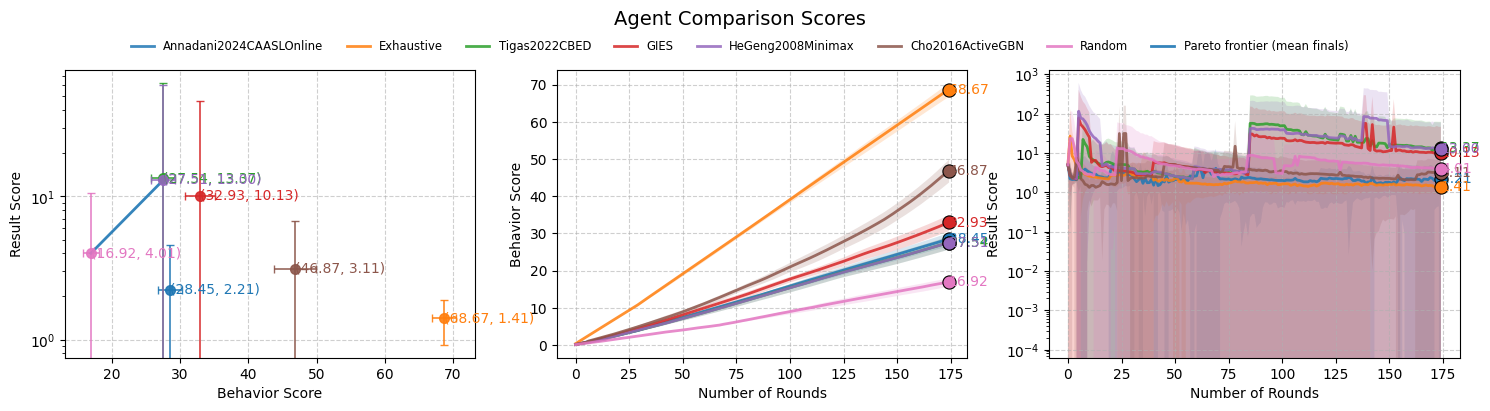

In [30]:
if __name__ == "__main__":
    agents = {
        "AgentA": (
            [[0.1, 0.2, 0.3], [0.12, 0.22, 0.28, 0.35]],  # behavior runs
            [[10, 8, 6], [11, 7, 5, 4.5]],  # result runs
        ),
        "AgentB": ([[0.05, 0.1, 0.15], [0.06, 0.11]], [[20, 18, 15], [19, 17]]),
    }
    fig, axes = plot_agents_mean_std(agent_scores)
    plt.show()
    pass